🔍 Lade Daten für Sonntag vs. Werktag-Vergleich...


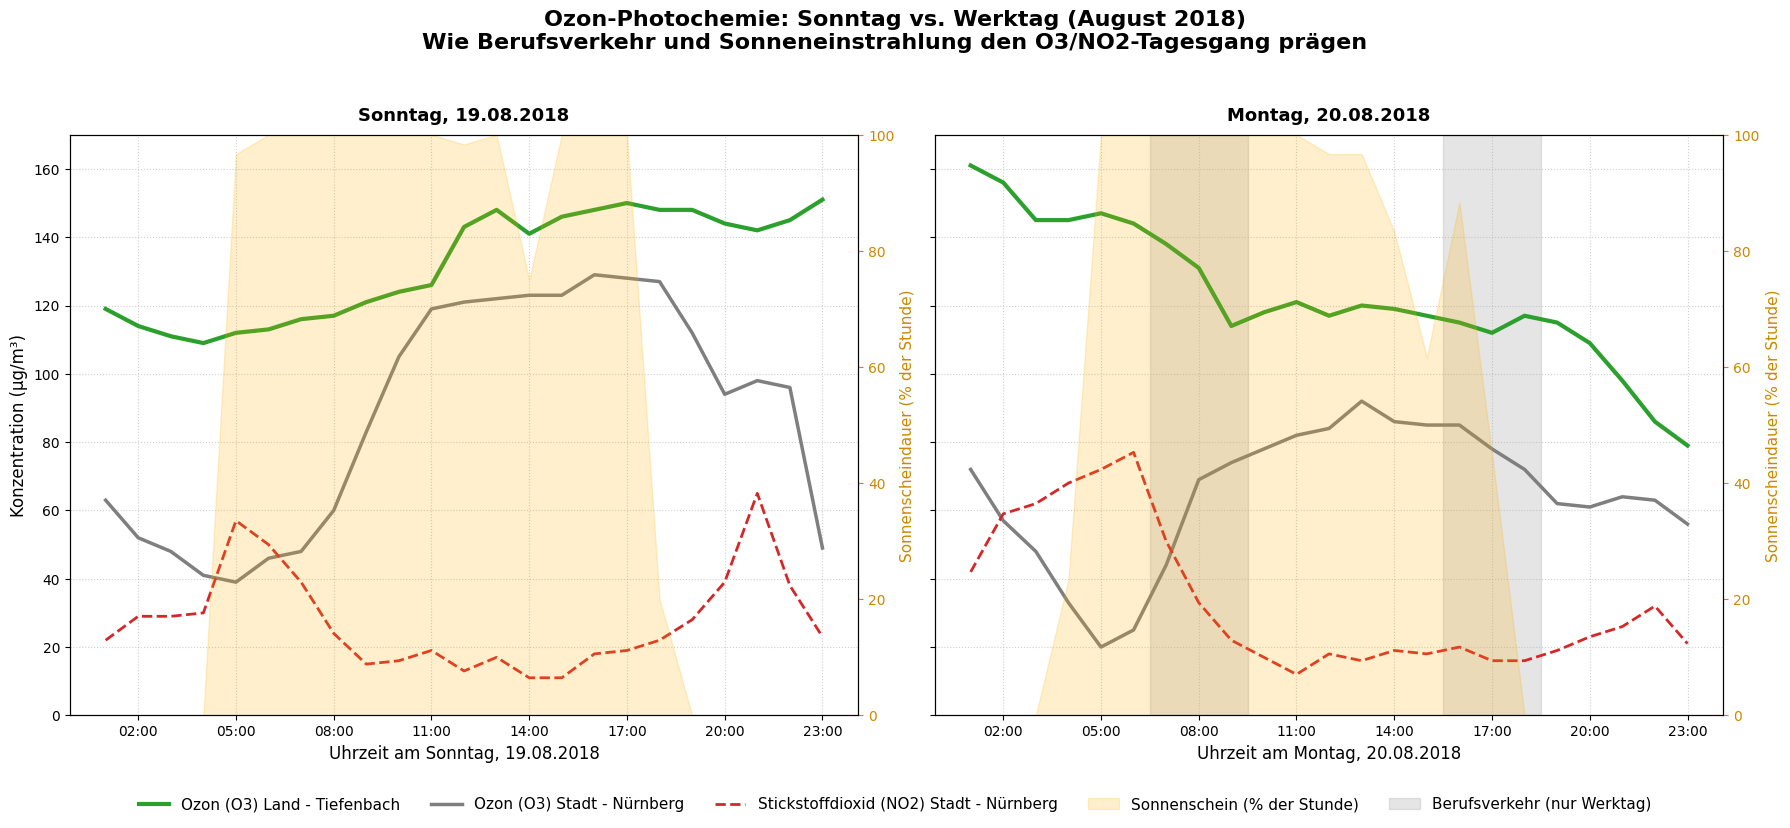

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

print("🔍 Lade Daten für Sonntag vs. Werktag-Vergleich...")

# ==========================================
# 1. Zeitfenster: Sonntag und Montag aus der Hitzewelle 2018
#    (Vergleich Verkehrsaufkommen: Werktag vs. Wochenende)
# ==========================================
tage = {
    '2018-08-19': 'Sonntag, 19.08.2018',
    '2018-08-20': 'Montag, 20.08.2018'
}

# ==========================================
# 2. Nürnberg (Stadt) - Stundenwerte laden
# ==========================================
df_stadt = pd.read_csv('../data/raw/data.csv')
df_stadt['timestamp'] = pd.to_datetime(df_stadt['datum']) + pd.to_timedelta(df_stadt['stunde'] - 1, unit='h')

# Alle nötigen Spalten extrahieren (inkl. Sonnenscheindauer)
df_stadt = df_stadt[['timestamp', 'o3', 'no2', 'sonnenscheindauer_minuten']].copy()
df_stadt.rename(columns={'o3': 'o3_stadt', 'no2': 'no2_stadt'}, inplace=True)

# Sonnenscheindauer (Minuten/h) in Prozent umrechnen für die Darstellung
df_stadt['sonne_prozent'] = df_stadt['sonnenscheindauer_minuten'] / 60 * 100

# ==========================================
# 3. Tiefenbach (Land) - aus vorbereiteter Parquet
# ==========================================
df_land = pd.read_parquet('../data/processed/o3_stundenwerte_2018_station_tiefenbach.parquet')

# ==========================================
# 4. Merge und Plotting
# ==========================================
df_merged = pd.merge(df_stadt, df_land, on='timestamp', how='inner')
df_merged.set_index('timestamp', inplace=True)
df_merged.sort_index(inplace=True)

# Subplots: zwei Tage nebeneinander, geteilte Y-Achse für Schadstoffe
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

for ax, (tag, label) in zip(axes, tage.items()):
    # Daten für diesen Tag filtern
    mask = (df_merged.index >= tag) & (df_merged.index <= tag + ' 23:59:59')
    df_tag = df_merged.loc[mask]
    
    if df_tag.empty:
        ax.text(0.5, 0.5, f'Keine Daten für {label}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # --- Sonnenscheindauer als Hintergrundfläche (zweite Y-Achse) ---
    ax2 = ax.twinx()
    ax2.fill_between(df_tag.index, 0, df_tag['sonne_prozent'],
                     color='#ffb000', alpha=0.20, zorder=0, label='Sonnenschein (% der Stunde)')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('Sonnenscheindauer (% der Stunde)', fontsize=11, color='#cc8800')
    ax2.tick_params(axis='y', colors='#cc8800')
    
    # --- Schadstoff-Linien (vordere Y-Achse) ---
    ax.plot(df_tag.index, df_tag['o3_land'], label='Ozon (O3) Land - Tiefenbach',
            color='#2ca02c', linewidth=3, zorder=3)
    ax.plot(df_tag.index, df_tag['o3_stadt'], label='Ozon (O3) Stadt - Nürnberg',
            color='#7f7f7f', linewidth=2.5, zorder=3)
    ax.plot(df_tag.index, df_tag['no2_stadt'], label='Stickstoffdioxid (NO2) Stadt - Nürnberg',
            color='#d62728', linestyle='--', linewidth=2, zorder=3)
    
    # --- Berufsverkehr-Zonen nur am Werktag ---
    is_werktag = pd.to_datetime(tag).weekday() < 5
    if is_werktag:
        day = pd.to_datetime(tag)
        ax.axvspan(day + pd.Timedelta(hours=6, minutes=30),
                   day + pd.Timedelta(hours=9, minutes=30),
                   color='gray', alpha=0.20, zorder=1)
        ax.axvspan(day + pd.Timedelta(hours=15, minutes=30),
                   day + pd.Timedelta(hours=18, minutes=30),
                   color='gray', alpha=0.20, zorder=1)
    
    # Achsen-Formatierung
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f'Uhrzeit am {label}', fontsize=12)
    ax.set_ylim(0, 170)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)

# Y-Label nur einmal links
axes[0].set_ylabel('Konzentration (µg/m³)', fontsize=12)

# Gemeinsame Legende unten
handles, labels = axes[0].get_legend_handles_labels()
handles.append(mpatches.Patch(color='#ffb000', alpha=0.20, label='Sonnenschein (% der Stunde)'))
labels.append('Sonnenschein (% der Stunde)')
handles.append(mpatches.Patch(color='gray', alpha=0.20, label='Berufsverkehr (nur Werktag)'))
labels.append('Berufsverkehr (nur Werktag)')

fig.legend(handles=handles, labels=labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=False, fontsize=11)

# Übergeordneter Titel
fig.suptitle('Ozon-Photochemie: Sonntag vs. Werktag (August 2018)\n'
             'Wie Berufsverkehr und Sonneneinstrahlung den O3/NO2-Tagesgang prägen',
             fontsize=16, fontweight='bold', y=1.00)

fig.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

🔍 Lade Daten für Sonntag vs. Werktag-Vergleich (Wetter-matched)...


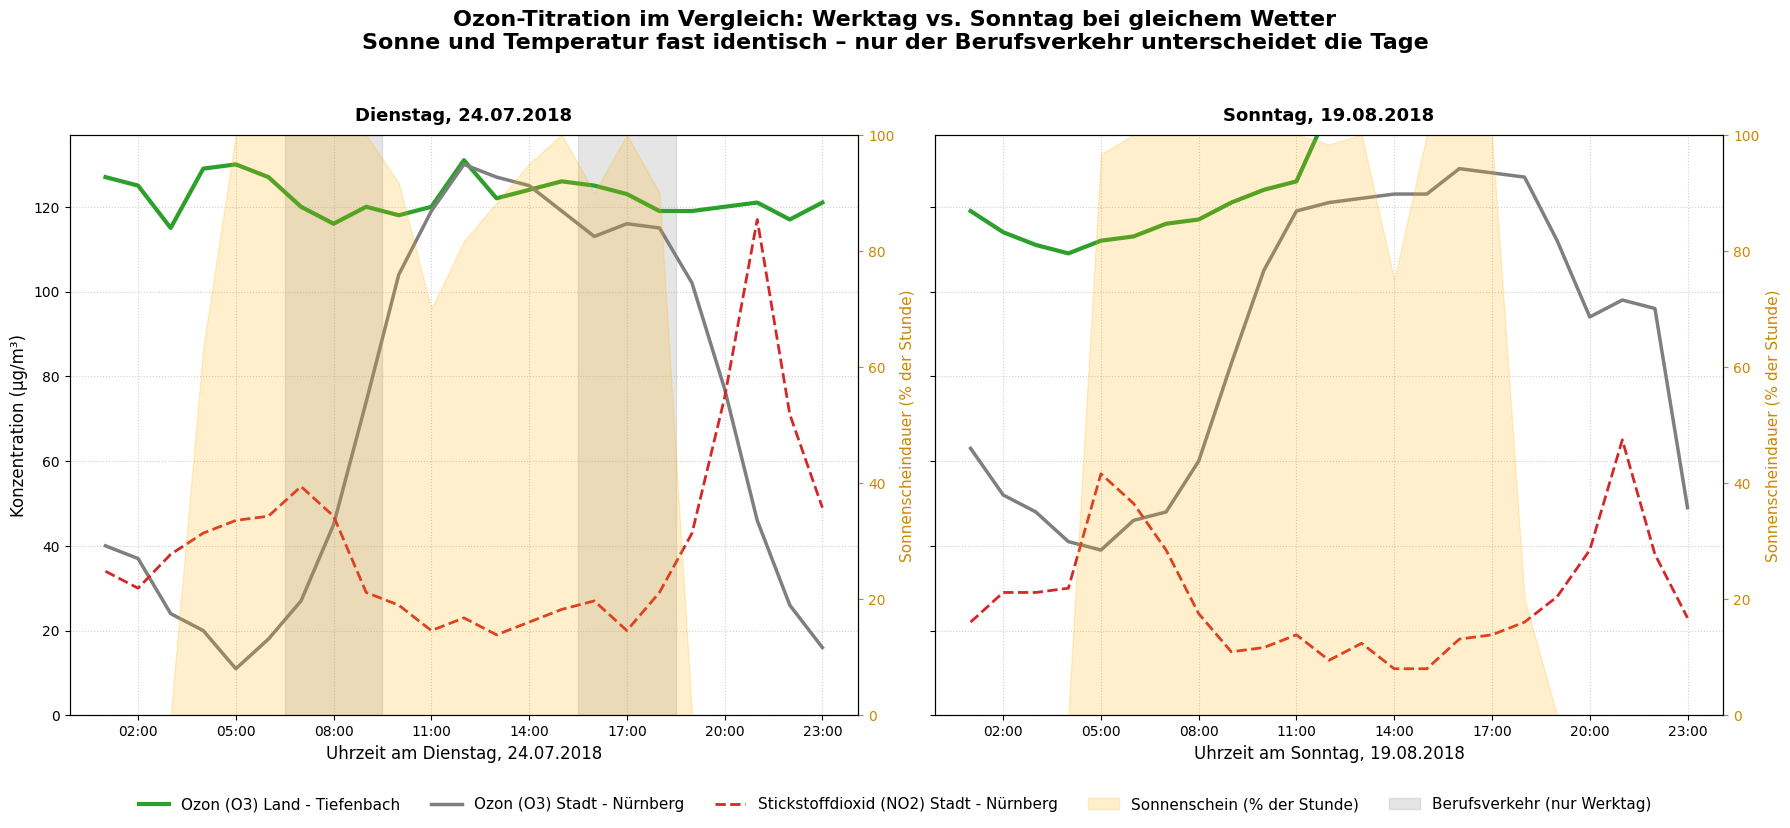

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

print("🔍 Lade Daten für Sonntag vs. Werktag-Vergleich (Wetter-matched)...")

# ==========================================
# 1. Wettergematchte Tage – nahezu identische Meteorologie:
#    Sonntag  19.08.2018: 774 Sonnenschein-Min, T_max 30.5 °C
#    Dienstag 24.07.2018: 822 Sonnenschein-Min, T_max 30.1 °C
#    → Einziger Unterschied: Berufsverkehr (NO₂-Eintrag)
# ==========================================
tage = {
    '2018-07-24': 'Dienstag, 24.07.2018',
    '2018-08-19': 'Sonntag, 19.08.2018'
}

# ==========================================
# 2. Nürnberg (Stadt) - Stundenwerte laden
# ==========================================
df_stadt = pd.read_csv('../data/raw/data.csv')
df_stadt['timestamp'] = pd.to_datetime(df_stadt['datum']) + pd.to_timedelta(df_stadt['stunde'] - 1, unit='h')

df_stadt = df_stadt[['timestamp', 'o3', 'no2', 'sonnenscheindauer_minuten']].copy()
df_stadt.rename(columns={'o3': 'o3_stadt', 'no2': 'no2_stadt'}, inplace=True)

# Sonnenscheindauer (Min/h) in Prozent umrechnen
df_stadt['sonne_prozent'] = df_stadt['sonnenscheindauer_minuten'] / 60 * 100

# ==========================================
# 3. Tiefenbach (Land) - aus vorbereiteter Parquet
# ==========================================
df_land = pd.read_parquet('../data/processed/o3_stundenwerte_2018_station_tiefenbach.parquet')

# ==========================================
# 4. Merge und Plotting
# ==========================================
df_merged = pd.merge(df_stadt, df_land, on='timestamp', how='inner')
df_merged.set_index('timestamp', inplace=True)
df_merged.sort_index(inplace=True)

# Subplots: zwei Tage nebeneinander, geteilte Y-Achse für Schadstoffe
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

for ax, (tag, label) in zip(axes, tage.items()):
    # Daten für diesen Tag filtern
    mask = (df_merged.index >= tag) & (df_merged.index <= tag + ' 23:59:59')
    df_tag = df_merged.loc[mask]
    
    if df_tag.empty:
        ax.text(0.5, 0.5, f'Keine Daten für {label}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # --- Sonnenscheindauer als Hintergrundfläche (zweite Y-Achse) ---
    ax2 = ax.twinx()
    ax2.fill_between(df_tag.index, 0, df_tag['sonne_prozent'],
                     color='#ffb000', alpha=0.20, zorder=0, label='Sonnenschein (% der Stunde)')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('Sonnenscheindauer (% der Stunde)', fontsize=11, color='#cc8800')
    ax2.tick_params(axis='y', colors='#cc8800')
    
    # --- Schadstoff-Linien (vordere Y-Achse) ---
    ax.plot(df_tag.index, df_tag['o3_land'], label='Ozon (O3) Land - Tiefenbach',
            color='#2ca02c', linewidth=3, zorder=3)
    ax.plot(df_tag.index, df_tag['o3_stadt'], label='Ozon (O3) Stadt - Nürnberg',
            color='#7f7f7f', linewidth=2.5, zorder=3)
    ax.plot(df_tag.index, df_tag['no2_stadt'], label='Stickstoffdioxid (NO2) Stadt - Nürnberg',
            color='#d62728', linestyle='--', linewidth=2, zorder=3)
    
    # --- Berufsverkehr-Zonen nur am Werktag ---
    is_werktag = pd.to_datetime(tag).weekday() < 5
    if is_werktag:
        day = pd.to_datetime(tag)
        ax.axvspan(day + pd.Timedelta(hours=6, minutes=30),
                   day + pd.Timedelta(hours=9, minutes=30),
                   color='gray', alpha=0.20, zorder=1)
        ax.axvspan(day + pd.Timedelta(hours=15, minutes=30),
                   day + pd.Timedelta(hours=18, minutes=30),
                   color='gray', alpha=0.20, zorder=1)
    
    # Achsen-Formatierung
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f'Uhrzeit am {label}', fontsize=12)
    ax.set_ylim(0, 170)
    ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
    ax.set_title(label, fontsize=13, fontweight='bold', pad=10)

# Y-Label nur einmal links
axes[0].set_ylabel('Konzentration (µg/m³)', fontsize=12)

# Gemeinsame Legende unten
handles, labels = axes[0].get_legend_handles_labels()
handles.append(mpatches.Patch(color='#ffb000', alpha=0.20, label='Sonnenschein (% der Stunde)'))
labels.append('Sonnenschein (% der Stunde)')
handles.append(mpatches.Patch(color='gray', alpha=0.20, label='Berufsverkehr (nur Werktag)'))
labels.append('Berufsverkehr (nur Werktag)')

fig.legend(handles=handles, labels=labels, loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=False, fontsize=11)

# Übergeordneter Titel
fig.suptitle('Ozon-Titration im Vergleich: Werktag vs. Sonntag bei gleichem Wetter\n'
             'Sonne und Temperatur fast identisch – nur der Berufsverkehr unterscheidet die Tage',
             fontsize=16, fontweight='bold', y=1.00)

fig.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()